# ARKK ETF Analysis with Fama-French 3-Factor Model

This notebook analyzes the **ARKK ETF** using the **Fama-French 3-Factor Model** to understand its risk exposures, performance, and market-neutral (alpha) component. Please refer to the dataset "F-F_Research_Data_Factors_daily.CSV" being used, and ensure that it is placed in the same directory as this notebook.

In [3]:
import pandas as pd
import yfinance as yf
import numpy as np 
import statsmodels.api as sm 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

#### Step 1: Load Fama-French 3 Factors and ARKK Data

Since our ff3 dataset only has data up till 2021, we will retrieve ARKK data dating from 2015 to 2021 (i.e 6 year horizon)

In [4]:
def load_ff3():
  ff3 = pd.read_csv('F-F_Research_Data_Factors_daily.CSV')
  ff3['Unnamed: 0'] = pd.DatetimeIndex(ff3['Unnamed: 0'].map(str))
  ff3 = ff3.set_index('Unnamed: 0') # Sets date index properly.
  return ff3[['Mkt-RF','SMB','HML']] / 100. # Loads daily Mkt-RF, SMB, HML factors. Divides by 100 to convert percentage returns → decimal.

ret = load_ff3()

# Download ARKK and Compute Returns
arkk = yf.download('ARKK', start='2015-01-01', end='2021-01-01')['Close']
arkk.index = arkk.index.date
ret['ARKK'] = arkk.pct_change()
ret = ret.dropna()

[*********************100%***********************]  1 of 1 completed


Let us visualise the cumulative performance of ARKK across time. Remember since we are conputing percentage change, we will need to add 1 and use cumprod instead of cumsum

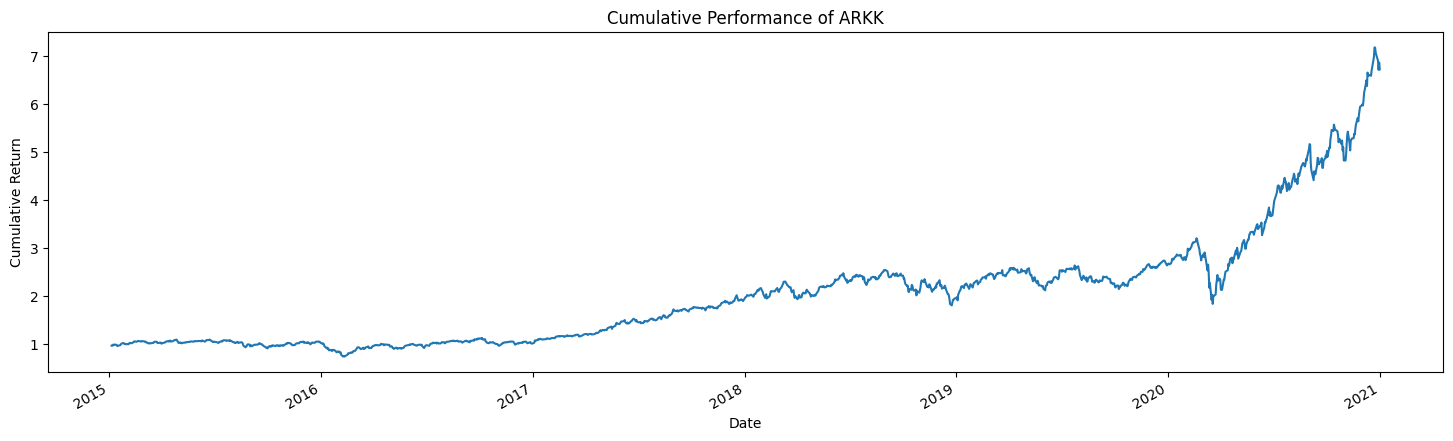

Cumulative return of ARKK over the period: 572.73%
Sharpe Ratio of ARKK: 1.2221


In [10]:
(ret['ARKK']+1).cumprod().plot()
plt.title('Cumulative Performance of ARKK')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gcf().set_size_inches(18, 5) # Increase the size of the plot for better visibility
plt.show()

print("Cumulative return of ARKK over the period: {:.2f}%".format((ret['ARKK']+1).prod() * 100 - 100))
print("Sharpe Ratio of ARKK: {:.4f}".format(ret['ARKK'].mean() / ret['ARKK'].std() * np.sqrt(252)))

#### Step 2: Full-Sample Fama-French Regression
**Goal**: Decompose **ARKK** and **QQQ** returns using **Fama-French 3-Factor** and **Carhart 4-Factor** models to assess risk exposures, alpha, and style drift.


In [11]:
X = ret[['Mkt-RF','SMB','HML']] # Independent variables
X = sm.add_constant(X) # Adds a constant term to the predictor

mod = sm.OLS( ret['ARKK'], X) # Defines the model
res = mod.fit() # Fits the model
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                   ARKK   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     1422.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:47:30   Log-Likelihood:                 4881.2
No. Observations:                1510   AIC:                            -9754.
Df Residuals:                    1506   BIC:                            -9733.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.112      0.0

In [12]:
# loadings
res.params

const     0.000521
Mkt-RF    1.233616
SMB       0.862925
HML      -0.656318
dtype: float64

In [13]:
# r-squared 
res.predict(X).var() / ret['ARKK'].var()

0.7391406621566966

**Contribution to Volatility**

How much each factor contributes to total portfolio volatility.

In [14]:
# risk contribution 
X.multiply(res.params).std()[['Mkt-RF','SMB','HML']] / ret['ARKK'].std()

Mkt-RF    0.784214
SMB       0.269987
HML       0.293081
dtype: float64

We can derive the estimated P&L impact from a 5-standard-deviation move in each factor

In [15]:
# x-std shock
(X[['Mkt-RF','SMB','HML']].std()*5)*res.params[['Mkt-RF','SMB','HML']].abs()

Mkt-RF    0.073318
SMB       0.025242
HML       0.027401
dtype: float64

In [16]:
# tstats
res.tvalues # Statistical significance of each factor loading.

const      2.111782
Mkt-RF    58.690716
SMB       20.304622
HML      -21.953597
dtype: float64

#### Step 3: Model Specification

We can neutralise our portfolio by substracting the 3 factors from our expected returns
$$
\text{neut}_t = r_{\text{ARKK},t} - \left(
\beta_{\text{MKT}} \cdot \mathrm{Mkt\!-\!RF}_t +
\beta_{\text{SMB}} \cdot \mathrm{SMB}_t +
\beta_{\text{HML}} \cdot \mathrm{HML}_t
\right)
$$

**Purpose**:

Removes systematic factor exposure and isolates idiosyncratic return ($\alpha$ and $\text{noise}$). This is the residual return after hedging out market, size, and value risks — ideal for evaluating true manager skill or stock-specific alpha.



In [17]:
# neutralized portfolio 
neut = ret['ARKK'] - X.multiply(res.params)[['Mkt-RF','SMB','HML']].sum(1)
neut

Unnamed: 0
2015-01-05   -0.008708
2015-01-06    0.013767
2015-01-07   -0.016082
2015-01-08   -0.000882
2015-01-09   -0.001126
                ...   
2020-12-24   -0.014707
2020-12-28   -0.021424
2020-12-29   -0.007335
2020-12-30    0.010882
2020-12-31   -0.014951
Length: 1510, dtype: float64

Plot the cumulative returns of the residual

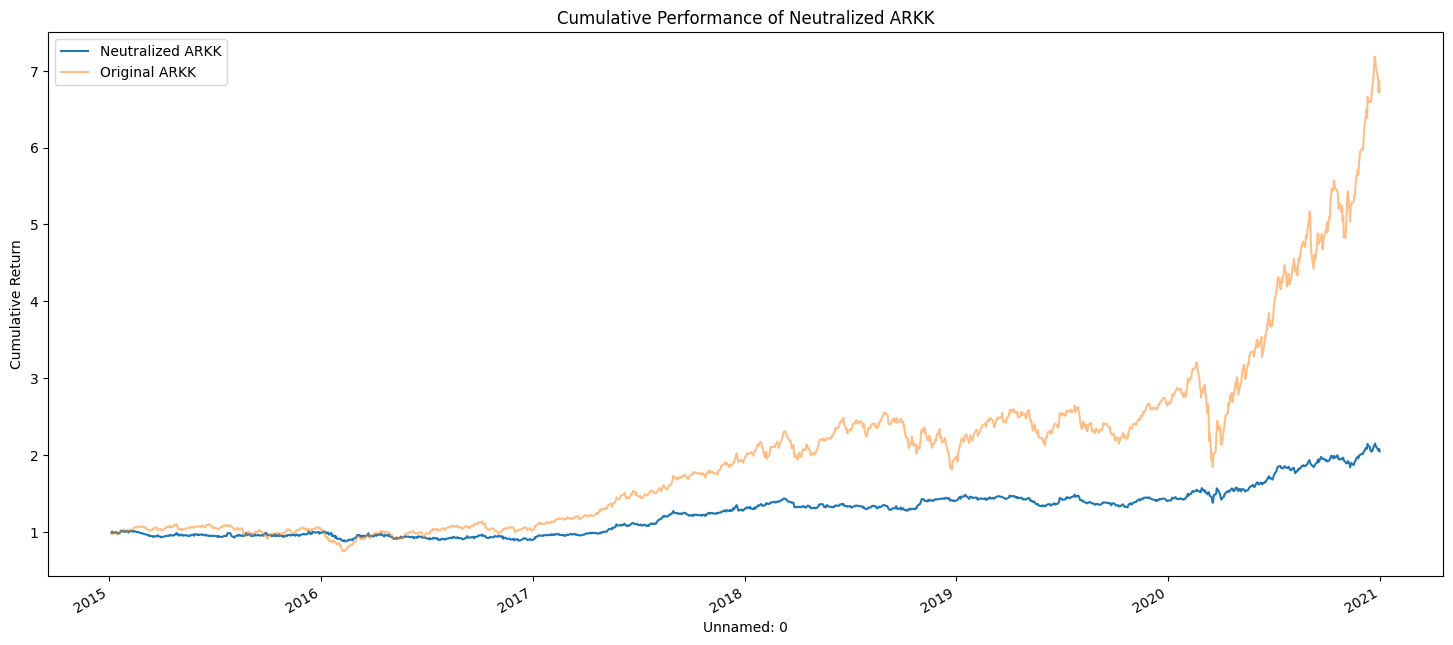

Cumulative return of Neutralized ARKK over the period: 104.89%
Sharpe Ratio of Neutralized ARKK: 0.8655


In [22]:
(neut + 1).cumprod().plot(label='Neutralized ARKK')
plt.title('Cumulative Performance of Neutralized ARKK')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.gcf().set_size_inches(18, 8) # Increase the size of the plot for better visibility

# Include the plot of the original ARKK for comparison 
(ret['ARKK']+1).cumprod().plot(label='Original ARKK', alpha=0.5)
plt.legend()
plt.show()

print("Cumulative return of Neutralized ARKK over the period: {:.2f}%".format((neut + 1).prod() * 100 - 100))
print("Sharpe Ratio of Neutralized ARKK: {:.4f}".format(neut.mean() / neut.std() * np.sqrt(252)))

#### Step 4: Rolling 1-Year Betas (Dynamic Factor Exposure)

This section estimates the Fama-French 3-factor regression on a rolling 252-day window. It tracks how ARKK’s exposures to Market, Size, and Value evolve over time.

**Why It Matters**: 
- Detects style drift — e.g., ARKK becoming more/less aggressive.
- Identifies regime changes — e.g., higher beta in bull markets.
- Improves risk modeling — static beta may misrepresent current risk.



In [23]:
# rolling betas for neutralization
def get_betas(ret):
  """
  Fit Fama-French 3-factor model on a given return DataFrame.
    
  Parameters:
    ret (pd.DataFrame): Must contain 'ARKK', 'Mkt-RF', 'SMB', 'HML'
    
  Returns:
    pd.Series: Regression coefficients (alpha, Mkt-RF, SMB, HML)
  """
  X = ret[['Mkt-RF','SMB','HML']]     # Select factor returns
  X = sm.add_constant(X)              # Add intercept (alpha)
  mod = sm.OLS(ret['ARKK'], X)        # Define OLS model
  res = mod.fit()                     # Fit model  
  return res.params

betas = {}
for dt in ret.index:
  # Define start of 1-year (252 trading days) lookback window
  start_dt = dt - pd.tseries.offsets.Day()*252
  # Slice data for the rolling window
  sub_ret = ret.loc[start_dt:dt]
  # Only estimate betas if enough data (min 60 days ~ 3 months)
  if len(sub_ret) > 60:
    betas[dt] = get_betas(sub_ret)

# Convert dictionary to DataFrame, transpose so dates are rows
betas = pd.DataFrame(betas).T

Plot to visualize time-varying factor exposures

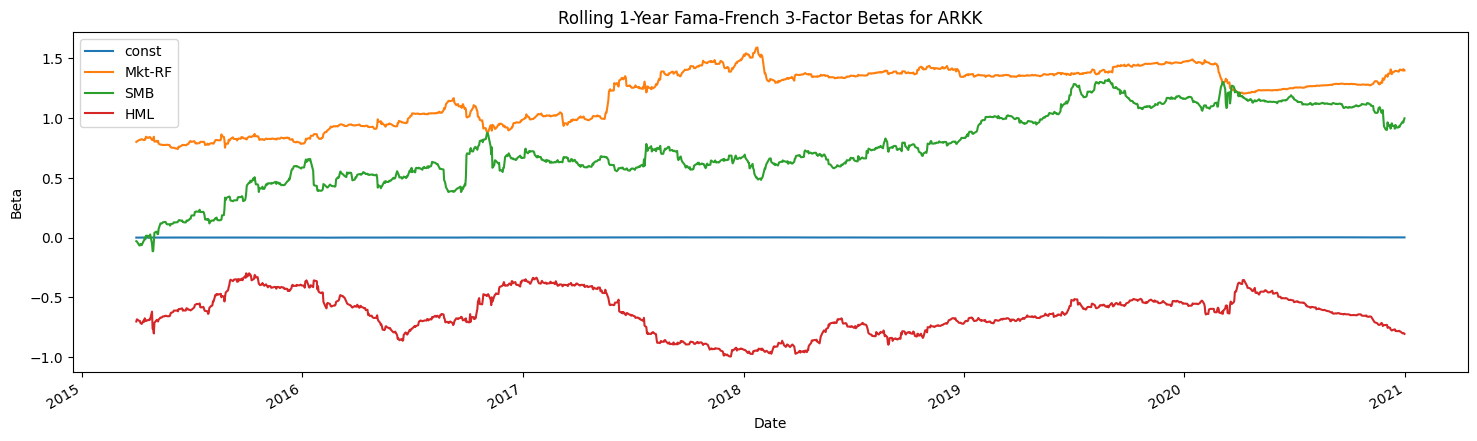

In [ ]:
betas.plot()
plt.title('Rolling 1-Year Fama-French 3-Factor Betas for ARKK')
plt.xlabel('Date')
plt.ylabel('Beta')
plt.gcf().set_size_inches(18, 5) # Increase the size of the
plt.show()

The plot reveals that ARKK’s factor exposures are not constant — critical for adaptive hedging or risk management.